In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Nature-style configuration
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 100
})

# Base Parameters
t_max = 90
t_eval = np.linspace(0, t_max, 150)
y0 = [0.99, 0.01, 0.00] # S0, I0, R0

beta_true = 0.4
gamma_true = 0.1
R0_true = beta_true / gamma_true

def sir(t, y, b, g):
    S, I, R = y
    return [-b * S * I, b * S * I - g * I, g * I]

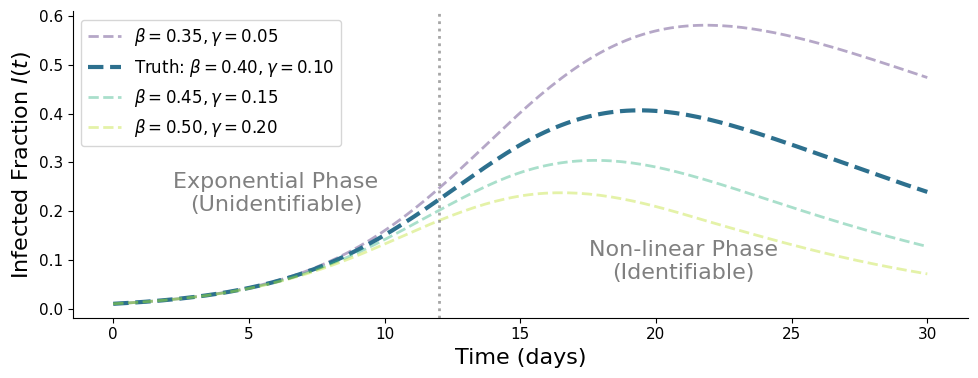

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Style Configuration
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12, # Increased legend font size
    'figure.dpi': 300
})

# Base Parameters
t_max = 30
t_eval = np.linspace(0, t_max, 150)
y0 = [0.99, 0.01, 0.00] # S0, I0, R0

beta_true = 0.4
gamma_true = 0.1
r_true = beta_true - gamma_true

def sir(t, y, b, g):
    S, I, R = y
    return [-b * S * I, b * S * I - g * I, g * I]

def plot_figure_1_corrected():
    fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

    # Pairs (beta, gamma) that keep r = 0.30 constant
    ambiguous_pairs = [
        (0.35, 0.05),
        (0.40, 0.10), # True Target
        (0.45, 0.15),
        (0.50, 0.20)
    ]

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ambiguous_pairs)))

    for (b, g), color in zip(ambiguous_pairs, colors):
        sol = solve_ivp(sir, [0, t_max], y0, args=(b, g), t_eval=t_eval)
        lw = 3.0 if b == beta_true else 2.0
        alpha = 1.0 if b == beta_true else 0.4

        label_str = rf'Truth: $\beta={b:.2f}, \gamma={g:.2f}$' if b == beta_true else rf'$\beta={b:.2f}, \gamma={g:.2f}$'

        ax.plot(t_eval, sol.y[1], color=color, lw=lw, ls='--', alpha=alpha, label=label_str)

    # --- START OF REGIME MARKING ---
    t_transition = 12 # Breakpoint of linear approximation

    # Dividing Line
    ax.axvline(x=t_transition, color='gray', linestyle=':', lw=2, alpha=0.7)

    # Texts demarcating zones
    ax.text(t_transition / 2, 0.2, 'Exponential Phase\n(Unidentifiable)',
            horizontalalignment='center', color='gray', fontsize=16)
    ax.text(t_transition + (t_max - t_transition)/2, 0.06, 'Non-linear Phase\n(Identifiable)',
            horizontalalignment='center', color='gray', fontsize=16)
    # --- END OF REGIME MARKING ---

    # ax.set_title(rf'Epidemic Dynamics ($β - γ = {r_true:.2f}$)') # Removed title
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Infected Fraction $I(t)$')
    ax.legend(frameon=True, loc='upper left', facecolor='white') # Added white background and frame

    plt.tight_layout()
    plt.show()

plot_figure_1_corrected()

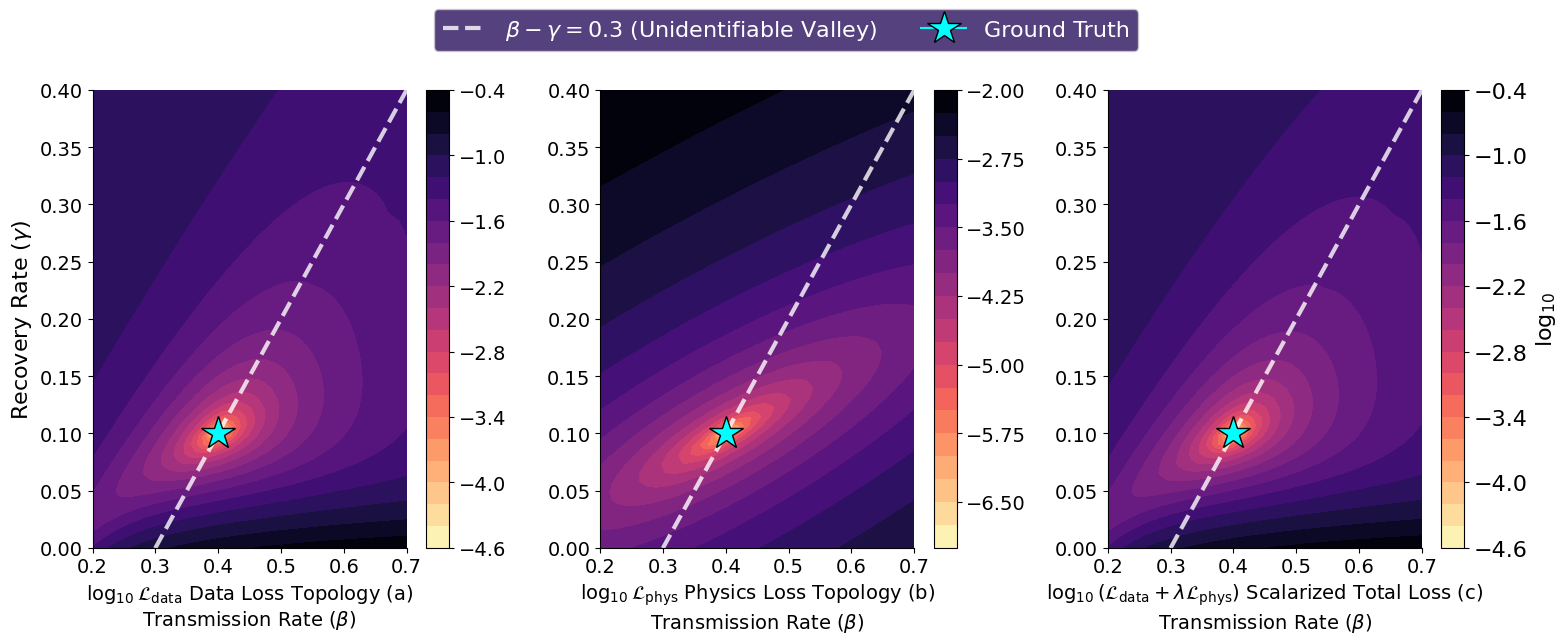

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- 1. Ground Truth Generation ---
beta_true, gamma_true = 0.4, 0.1
t_span = [0, 30]
t_eval = np.linspace(0, 30, 300)
y0 = [0.99, 0.01, 0.0]

def sir_model(t, y, b, g):
    S, I, R = y
    return [-b*S*I, b*S*I - g*I, g*I]

sol_true = solve_ivp(sir_model, t_span, y0, args=(beta_true, gamma_true), t_eval=t_eval)
I_true = sol_true.y[1]
S_true = sol_true.y[0]

# Precompute derivatives for Physics Loss
dS_dt_true = -beta_true * S_true * I_true
dI_dt_true = beta_true * S_true * I_true - gamma_true * I_true

# --- 2. Parametric Sweep Setup ---
beta_range = np.linspace(0.2, 0.7, 50)
gamma_range = np.linspace(0.0, 0.4, 50)
B, G = np.meshgrid(beta_range, gamma_range)

data_loss = np.zeros_like(B)
phys_loss = np.zeros_like(B)

for i in range(len(gamma_range)):
    for j in range(len(beta_range)):
        b, g = B[i, j], G[i, j]

        # Data Loss: solve ODE with current b, g and compare I(t)
        sol_test = solve_ivp(sir_model, t_span, y0, args=(b, g), t_eval=t_eval)
        data_loss[i, j] = np.mean((sol_test.y[1] - I_true)**2)

        # Physics Loss: Evaluate residuals of the TRUE trajectory using current b, g
        res_i = dI_dt_true - (b * S_true * I_true - g * I_true)
        phys_loss[i, j] = np.mean(res_i**2)

# Total Loss (unit weights)
total_loss = data_loss + phys_loss

# --- 3. Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(16, 6))
landscapes = [data_loss, phys_loss, total_loss]

# Labels and math parts for embedding
original_titles_text = ['Data Loss Topology', 'Physics Loss Topology', 'Scalarized Total Loss']
original_titles_prefix = ['a', 'b', 'c']

colorbar_math_parts = [
    r'$\log_{10} \mathcal{L}_{\mathrm{data}}$',
    r'$\log_{10} \mathcal{L}_{\mathrm{phys}}$',
    r'$\log_{10} (\mathcal{L}_{\mathrm{data}} + \lambda \mathcal{L}_{\mathrm{phys}})$'
]

for i, ax in enumerate(axs):
    cp = ax.contourf(B, G, np.log10(landscapes[i] + 1e-10), levels=20, cmap='magma_r')

    # Colorbar logic: only on the last plot, label 'log10'
    if i == 2:
        cb = fig.colorbar(cp, ax=ax, label=r'$\log_{10}$')
        cb.ax.tick_params(labelsize=16)
    else:
        cb = fig.colorbar(cp, ax=ax, label='')
        cb.ax.tick_params(labelsize=14)

    # Plot unidentifiable line as a legend entry (thicker line)
    unidentifiable_line, = ax.plot(beta_range, beta_range - 0.3, 'w--', lw=3, alpha=0.8, label=r'$\beta - \gamma = 0.3$ (Unidentifiable Valley)')

    # Plot Truth (Larger Star)
    ax.plot(beta_true, gamma_true, 'cyan', marker='*', markersize=25, markeredgecolor='black', label='Ground Truth')

    # Construct x-axis label with newline breaks
    x_label = f"{colorbar_math_parts[i]} {original_titles_text[i]} ({original_titles_prefix[i]})\nTransmission Rate ($\\beta$)"
    ax.set_xlabel(x_label, fontsize=14)

    # Y axis titles: Increase size and only show for the first plot
    if i == 0:
        ax.set_ylabel(r'Recovery Rate ($\gamma$)', fontsize=16)
    else:
        ax.set_ylabel('')

    ax.set_xlim(0.2, 0.7)
    ax.set_ylim(0.0, 0.4)

# Global legend at top - Explicit handles for Legend clarity
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles=handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2, frameon=True, facecolor='#2C115F', fontsize=16, labelcolor='white')

plt.tight_layout()
plt.show()

Calculating Hessians via finite differences...


/tmp/ipykernel_1851/22364066.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for the legend at the top


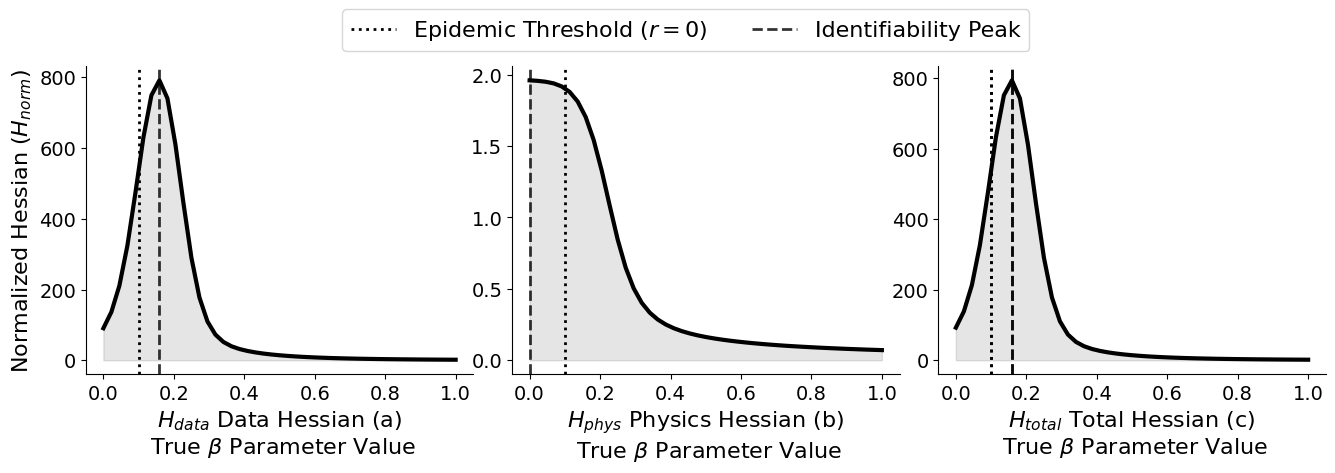

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.gridspec as gridspec

# Style Configuration
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 16, # Overall font size
    'axes.labelsize': 16, # Axis labelsize increased to 16
    'axes.titlesize': 16, # Title size (though titles are now removed)
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 14, # X-tick labelsize increased to 14
    'ytick.labelsize': 14, # Y-tick labelsize increased to 14
    'legend.fontsize': 16, # Legend font size
    'figure.dpi': 100
})

# Base Parameters
t_max = 30
t_eval = np.linspace(0, t_max, 150)
y0 = [0.99, 0.01, 0.00]

gamma_true = 0.1
lambda_phys = 1.0 # Scalarization weight

def sir(t, y, b, g):
    S, I, R = y
    return [-b * S * I, b * S * I - g * I, g * I]

def format_hessian_panel(ax, y_data, b_range, title_suffix, show_ylabel):
    # All curve colors black
    ax.plot(b_range, y_data, color='black', lw=3.0)
    ax.fill_between(b_range, 0, y_data, color='black', alpha=0.1)

    ax.axvline(x=gamma_true, color='black', linestyle=':', lw=2)
    max_idx = np.argmax(y_data)
    # Identifiability peak is now black
    ax.axvline(x=b_range[max_idx], color='black', linestyle='--', lw=2, alpha=0.8)

    # Removed titles
    # ax.set_title(title, loc='left')

    # Integrate hessian type into x-axis label
    ax.set_xlabel(rf'{title_suffix} True $\beta$ Parameter Value')

    if show_ylabel:
        ax.set_ylabel(r'Normalized Hessian ($H_{norm}$)')
    else:
        ax.set_ylabel('') # Ensure no ylabel


def plot_hessian_scalarization_r():
    fig = plt.figure(figsize=(16, 4), dpi=100)
    gs = gridspec.GridSpec(1, 3, wspace=0.1)

    b_range = np.linspace(0.0, 1.0, 45)
    h_step = 0.005

    hn_data = []
    hn_phys = []
    hn_total = []

    print("Calculating Hessians via finite differences...")
    for b_val in b_range:
        # 1. Base Trajectory
        sol_ref = solve_ivp(sir, [0, t_max], y0, args=(b_val, gamma_true), t_eval=t_eval)
        S_ref = sol_ref.y[0]
        I_ref = sol_ref.y[1]
        dI_dt_ref = b_val * S_ref * I_ref - gamma_true * I_ref

        energy = np.sum(I_ref**2)

        loss_d = []
        loss_p = []

        # 2. Perturbations in beta
        for shift in [-h_step, 0, h_step]:
            b_shift = b_val + shift

            # Data Loss
            sol_shift = solve_ivp(sir, [0, t_max], y0, args=(b_shift, gamma_true), t_eval=t_eval)
            mse_data = np.sum((sol_shift.y[1] - I_ref)**2)
            loss_d.append(mse_data)

            # Physics Loss
            residual = dI_dt_ref - (b_shift * S_ref * I_ref - gamma_true * I_ref)
            mse_phys = np.sum(residual**2)
            loss_p.append(mse_phys)

        # 3. Central Derivative
        hess_data = (loss_d[2] - 2*loss_d[1] + loss_d[0]) / (h_step**2)
        hess_phys = (loss_p[2] - 2*loss_p[1] + loss_p[0]) / (h_step**2)
        hess_tot  = hess_data + lambda_phys * hess_phys

        # 4. Normalization
        if energy > 1e-8:
            hn_data.append(hess_data / energy)
            hn_phys.append(hess_phys / energy)
            hn_total.append(hess_tot / energy)
        else:
            hn_data.append(0)
            hn_phys.append(0)
            hn_total.append(0)

    ax1 = fig.add_subplot(gs[0])
    format_hessian_panel(ax1, hn_data, b_range, r'$H_{data}$ Data Hessian (a)' + '\n', show_ylabel=True)

    ax2 = fig.add_subplot(gs[1])
    format_hessian_panel(ax2, hn_phys, b_range, r'$H_{phys}$ Physics Hessian (b)' + '\n', show_ylabel=False)

    ax3 = fig.add_subplot(gs[2])
    format_hessian_panel(ax3, hn_total, b_range, r'$H_{total}$ Total Hessian (c)' + '\n', show_ylabel=False)

    # Legend should only contain epidemic threshold and identifiability peak
    handles = []
    labels = []

    # Add vertical line labels directly to ax3
    # Re-plot axvlines with labels on ax3 for the legend only
    max_idx_total = np.argmax(hn_total) # Use the max_idx from the total Hessian for consistency

    vline_handle1 = ax3.axvline(x=gamma_true, color='black', linestyle=':', lw=2, label=r'Epidemic Threshold ($r=0$)')
    handles.append(vline_handle1)
    labels.append(r'Epidemic Threshold ($r=0$)')

    vline_handle2 = ax3.axvline(x=b_range[max_idx_total], color='black', linestyle='--', lw=2, alpha=0.8, label='Identifiability Peak')
    handles.append(vline_handle2)
    labels.append('Identifiability Peak')

    # Place the legend at the top of the figure
    fig.legend(handles, labels, frameon=True, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, facecolor='white', fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect to make space for the legend at the top
    plt.show()

plot_hessian_scalarization_r()

/tmp/ipykernel_3932/1562816074.py:14: RuntimeWarning: divide by zero encountered in divide
  ee_branch = 1 - (gamma / beta_range)


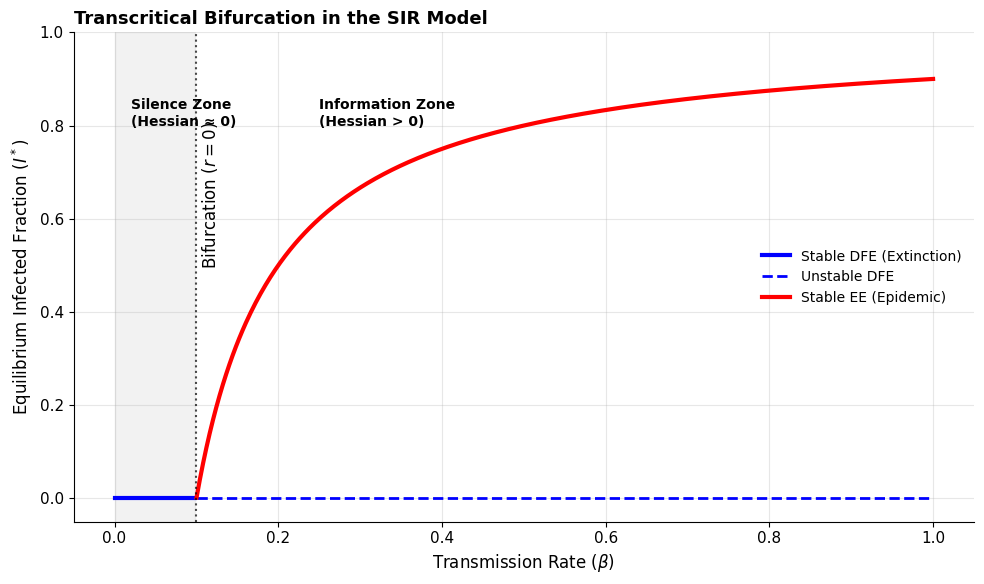

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sir_bifurcation():
    # Parameters
    gamma = 0.1
    beta_range = np.linspace(0, 1.0, 500)

    # Steady States
    # 1. Disease-Free Equilibrium (DFE): I* = 0
    # 2. Endemic Equilibrium (EE): I* = 1 - (gamma/beta)

    dfe_branch = np.zeros_like(beta_range)
    ee_branch = 1 - (gamma / beta_range)

    # Adjustment for physical values (I cannot be negative in EE)
    ee_branch[beta_range <= gamma] = np.nan

    plt.figure(figsize=(10, 6), dpi=100)

    # Plotting the Disease-Free Equilibrium (I*=0)
    # Stable when beta < gamma (r < 0)
    plt.plot(beta_range[beta_range <= gamma], dfe_branch[beta_range <= gamma],
             'b-', lw=3, label='Stable DFE (Extinction)')
    # Unstable when beta > gamma (r > 0)
    plt.plot(beta_range[beta_range > gamma], dfe_branch[beta_range > gamma],
             'b--', lw=2, label='Unstable DFE')

    # Plotting the Endemic Equilibrium
    # Stable when beta > gamma (r > 0)
    plt.plot(beta_range[beta_range > gamma], ee_branch[beta_range > gamma],
             'r-', lw=3, label='Stable EE (Epidemic)')

    # Critical Line (Bifurcation at r=0)
    plt.axvline(x=gamma, color='black', linestyle=':', alpha=0.7)
    plt.text(gamma + 0.005, 0.5, r'Bifurcation ($r=0$)', rotation=90, fontsize=12)

    # Analytical Annotations
    plt.fill_between(beta_range[beta_range <= gamma], -0.05, 1, color='gray', alpha=0.1)
    plt.text(0.02, 0.8, "Silence Zone\n(Hessian ≈ 0)", fontsize=10, fontweight='bold')
    plt.text(0.25, 0.8, "Information Zone\n(Hessian > 0)", fontsize=10, fontweight='bold')

    plt.title('Transcritical Bifurcation in the SIR Model', loc='left', fontweight='bold')
    plt.xlabel(r'Transmission Rate ($β$)')
    plt.ylabel(r'Equilibrium Infected Fraction ($I^*$)')
    plt.ylim(-0.05, 1.0)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()

plot_sir_bifurcation()

In [95]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Ground Truth ---
t_max = 30
t_eval = np.linspace(0, t_max, 100)
beta_t, gamma_t = 0.3, 0.1
y0 = [0.99, 0.01, 0.0]

def sir_model(t, y, b, g):
    S, I, R = y
    return [-b*S*I, b*S*I - g*I, g*I]

sol = solve_ivp(sir_model, [0, t_max], y0, args=(beta_t, gamma_t), t_eval=t_eval)
I_obs = torch.tensor(sol.y[1], dtype=torch.float32).view(-1, 1).to(device)
t_tensor = torch.tensor(t_eval, dtype=torch.float32).view(-1, 1).to(device)

# --- 2. PINN ---
class ResearchPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )
    def forward(self, t): return self.net(t)

# --- 3. Training Engine ---
def train_hybrid(beta_val):
    model = ResearchPINN().to(device)
    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, line_search_fn="strong_wolfe")
    logs = {'data': [], 'phys': []}
    def get_loss():
        t_p = t_tensor.clone().requires_grad_(True)
        u = model(t_p); S, I, R = u[:,0:1], u[:,1:2], u[:,2:3]
        ds = torch.autograd.grad(S, t_p, torch.ones_like(S), create_graph=True)[0]
        di = torch.autograd.grad(I, t_p, torch.ones_like(I), create_graph=True)[0]
        dr = torch.autograd.grad(R, t_p, torch.ones_like(R), create_graph=True)[0]
        res_s = ds + beta_val * S * I
        res_i = di - (beta_val * S * I - gamma_t * I)
        res_r = dr - gamma_t * I
        l_phys = torch.mean(res_s**2 + res_i**2 + res_r**2)
        l_data = torch.mean((I - I_obs)**2)
        l_cons = torch.mean((S + I + R - 1.0)**2)
        return l_data + l_phys + l_cons, l_data, l_phys
    for _ in range(5000):
        adam.zero_grad(); total, ld, lp = get_loss(); total.backward(); adam.step()
        logs['data'].append(ld.item()); logs['phys'].append(lp.item())
    def closure():
        lbfgs.zero_grad(); total, _, _ = get_loss(); total.backward(); return total
    lbfgs.step(closure)
    return model, logs

print("Training...")
model_d, logs_d = train_hybrid(0.5)
model_t, _ = train_hybrid(0.3)



Training...


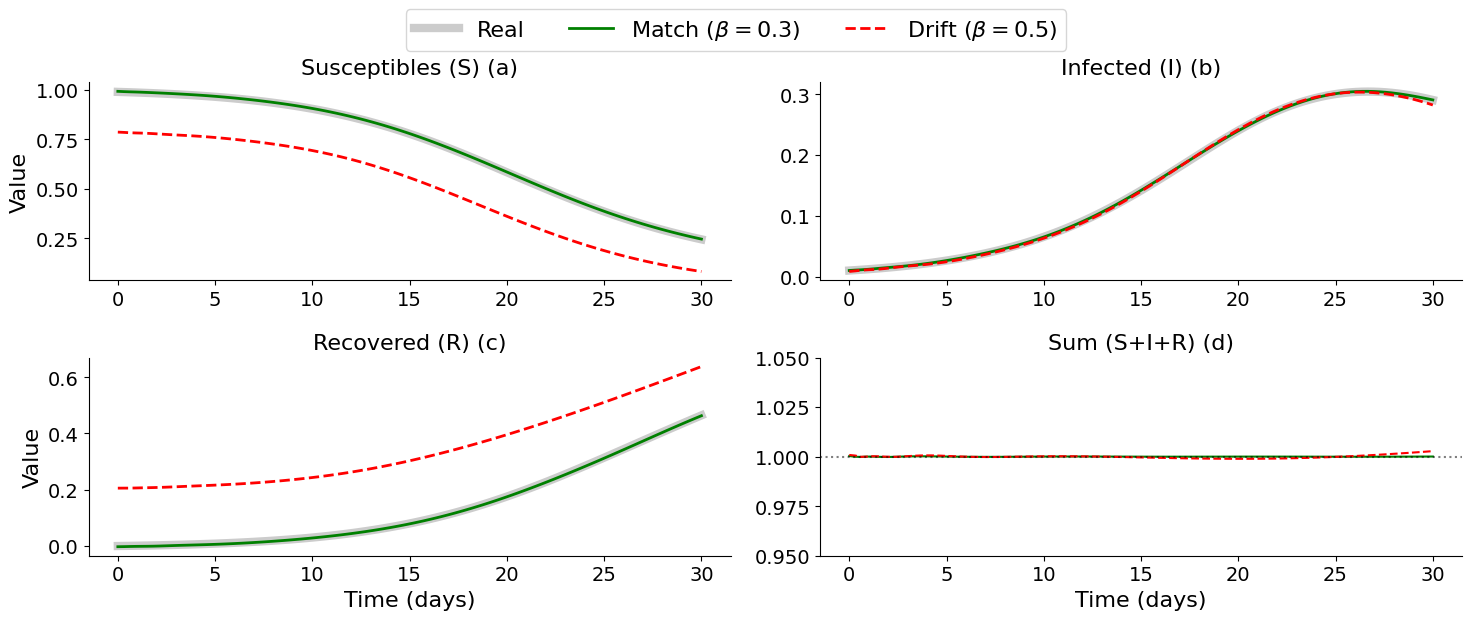

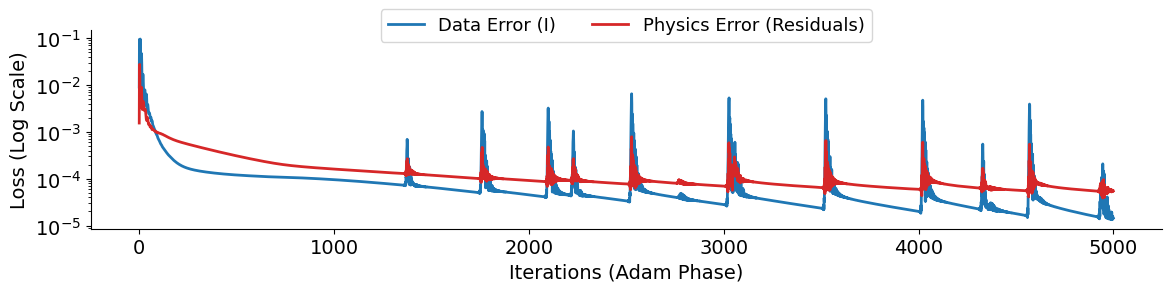

In [96]:
# --- 4. Plotting ---
with torch.no_grad():
    res_t = model_t(t_tensor).cpu(); res_d = model_d(t_tensor).cpu()

fig1, axs = plt.subplots(2, 2, figsize=(15, 6))
compartment_titles = ['Susceptibles (S) (a)', 'Infected (I) (b)', 'Recovered (R) (c)', 'Sum (S+I+R) (d)']

for i in range(3):
    ax = axs[i//2, i%2]
    line_real, = ax.plot(t_eval, sol.y[i], 'k-', alpha=0.2, lw=6, label='Real')
    line_match, = ax.plot(t_eval, res_t[:, i], 'g-', lw=2, label=r'Match ($\beta = 0.3$)')
    line_drift, = ax.plot(t_eval, res_d[:, i], 'r--', lw=2, label=r'Drift ($\beta = 0.5$)')
    ax.set_title(compartment_titles[i], fontsize=16)
    ax.grid(False)

    # Shared Y titles (First Column: subplots 0 and 2)
    if (i % 2) == 0:
        ax.set_ylabel('Value', fontsize=16)
    # Shared X titles (Second Row: subplots 2 and 3)
    if (i // 2) == 1:
        ax.set_xlabel('Time (days)', fontsize=16)

ax_sum = axs[1, 1]
ax_sum.plot(t_eval, torch.sum(res_t, dim=1), 'g-')
ax_sum.plot(t_eval, torch.sum(res_d, dim=1), 'r--')
ax_sum.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
ax_sum.set_title(compartment_titles[3], fontsize=16)
ax_sum.set_ylim(0.95, 1.05)
ax_sum.grid(False)
ax_sum.set_xlabel('Time (days)', fontsize=16) # Always second row

# Unified Legend for Figure 1
handles = [line_real, line_match, line_drift]
fig1.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=True, facecolor='white', fontsize=16)
plt.tight_layout()
plt.show()

# Loss Decomposition Plot
plt.figure(figsize=(12, 3))
plt.plot(logs_d['data'], label='Data Error (I)', color='#1f77b4', lw=2)
plt.plot(logs_d['phys'], label='Physics Error (Residuals)', color='#d62728', lw=2)
plt.yscale('log')
plt.xlabel('Iterations (Adam Phase)', fontsize=14)
plt.ylabel('Loss (Log Scale)', fontsize=14)
plt.tight_layout()
plt.grid(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=True, facecolor='white', fontsize=13)
plt.show()

Training Window 1/3...
Training Window 2/3...
Training Window 3/3...


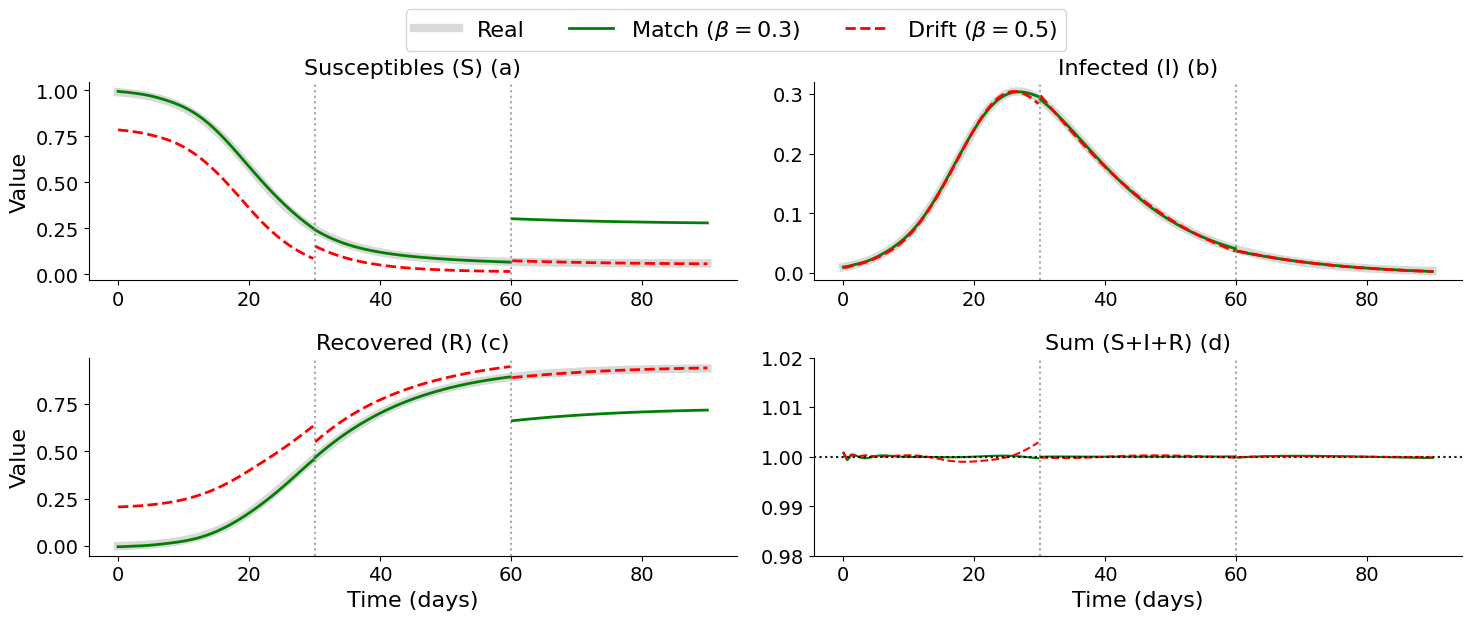

In [92]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

t_max = 90
t_eval = np.linspace(0, t_max, 300)
beta_t, gamma_t = 0.3, 0.1
y0 = [0.99, 0.01, 0.0]

def sir_model(t, y, b, g):
    S, I, R = y
    return [-b*S*I, b*S*I - g*I, g*I]

sol_ode = solve_ivp(sir_model, [0, t_max], y0, args=(beta_t, gamma_t), t_eval=t_eval)

class ResearchPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )
    def forward(self, t): return self.net(t)

def train_window(t_slice, I_slice, beta_val):
    model = ResearchPINN().to(device)
    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, line_search_fn="strong_wolfe")
    t_tensor_win = torch.tensor(t_slice, dtype=torch.float32).view(-1, 1).to(device)
    I_obs_win = torch.tensor(I_slice, dtype=torch.float32).view(-1, 1).to(device)

    def get_loss():
        t_p = t_tensor_win.clone().requires_grad_(True)
        u = model(t_p); S, I, R = u[:,0:1], u[:,1:2], u[:,2:3]
        ds = torch.autograd.grad(S, t_p, torch.ones_like(S), create_graph=True)[0]
        di = torch.autograd.grad(I, t_p, torch.ones_like(I), create_graph=True)[0]
        dr = torch.autograd.grad(R, t_p, torch.ones_like(R), create_graph=True)[0]
        res_s = ds + beta_val * S * I
        res_i = di - (beta_val * S * I - gamma_t * I)
        res_r = dr - gamma_t * I
        l_phys = torch.mean(res_s**2 + res_i**2 + res_r**2)
        l_data = torch.mean((I - I_obs_win)**2)
        l_cons = torch.mean((S + I + R - 1.0)**2)
        return l_data + l_phys + l_cons, l_data, l_phys

    for _ in range(5000):
        adam.zero_grad(); total, _, _ = get_loss(); total.backward(); adam.step()
    def closure():
        lbfgs.zero_grad(); total, _, _ = get_loss(); total.backward(); return total
    lbfgs.step(closure)
    return model

def run_windowed_simulation(duration):
    window_limits = np.arange(0, t_max + 1, duration)
    num_windows = len(window_limits) - 1
    results_t, results_d = [], []
    for i in range(num_windows):
        start, end = window_limits[i], window_limits[i+1]
        mask = (t_eval >= start) & (t_eval <= end)
        t_win, I_win = t_eval[mask], sol_ode.y[1][mask]
        print(f"Training Window {i+1}/{num_windows}...")
        m_t = train_window(t_win, I_win, 0.3)
        m_d = train_window(t_win, I_win, 0.5)
        with torch.no_grad():
            t_ten = torch.tensor(t_win, dtype=torch.float32).view(-1, 1).to(device)
            results_t.append(m_t(t_ten).cpu().numpy())
            results_d.append(m_d(t_ten).cpu().numpy())
    return window_limits, results_t, results_d

def plot_windowed_results(window_limits, results_t, results_d, sol_ref, t_eval_ref):
    plt.rcParams.update({'font.size': 16})
    fig, axs = plt.subplots(2, 2, figsize=(15, 6))
    titles = ['Susceptibles (S) (a)', 'Infected (I) (b)', 'Recovered (R) (c)', 'Sum (S+I+R) (d)']
    for i in range(len(window_limits) - 1):
        start, end = window_limits[i], window_limits[i+1]
        mask = (t_eval_ref >= start) & (t_eval_ref <= end)
        t_win = t_eval_ref[mask]
        res_t, res_d = results_t[i], results_d[i]
        for j in range(3):
            ax = axs[j//2, j%2]
            if i == 0:
                l_real, = ax.plot(t_eval_ref, sol_ref.y[j], 'k-', alpha=0.15, lw=6, label='Real')
                # Shared Y titles (First Column)
                if (j%2) == 0: ax.set_ylabel('Value')
                # Shared X titles (Second Row)
                if (j//2) == 1: ax.set_xlabel('Time (days)')
            l_match, = ax.plot(t_win, res_t[:, j], 'g-', lw=2, label=r'Match ($\beta=0.3$)' if i==0 else "")
            l_drift, = ax.plot(t_win, res_d[:, j], 'r--', lw=2, label=r'Drift ($\beta=0.5$)' if i==0 else "")
            ax.set_title(titles[j], fontsize=16, fontweight='normal')
            for k in range(1, len(window_limits)-1): ax.axvline(x=window_limits[k], color='gray', ls=':', alpha=0.3)
        ax_s = axs[1, 1]
        ax_s.plot(t_win, np.sum(res_t, axis=1), 'g-')
        ax_s.plot(t_win, np.sum(res_d, axis=1), 'r--')
        ax_s.axhline(y=1.0, color='black', ls=':', alpha=0.5)
        ax_s.set_title(titles[3], fontsize=16, fontweight='normal')
        ax_s.set_ylim(0.98, 1.02)
        ax_s.set_xlabel('Time (days)') # Always second row
        for k in range(1, len(window_limits)-1): ax_s.axvline(x=window_limits[k], color='gray', ls=':', alpha=0.3)
    handles = [l_real, l_match, l_drift]
    labels = ['Real', r'Match ($\beta=0.3$)', r'Drift ($\beta=0.5$)']
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=True, facecolor='white', fontsize=16)
    plt.tight_layout()
    plt.show()

win_limits, res_t, res_d = run_windowed_simulation(30)
plot_windowed_results(win_limits, res_t, res_d, sol_ode, t_eval)

Running simulation with WINDOW_DURATION = 30 days (Hard ICs)
Training Green Window 1/3 (Beta 0.3)...
Training Red Window 1/3 (Beta 0.5)...
Training Green Window 2/3 (Beta 0.3)...
Training Red Window 2/3 (Beta 0.3)...
Training Green Window 3/3 (Beta 0.3)...
Training Red Window 3/3 (Beta 0.3)...


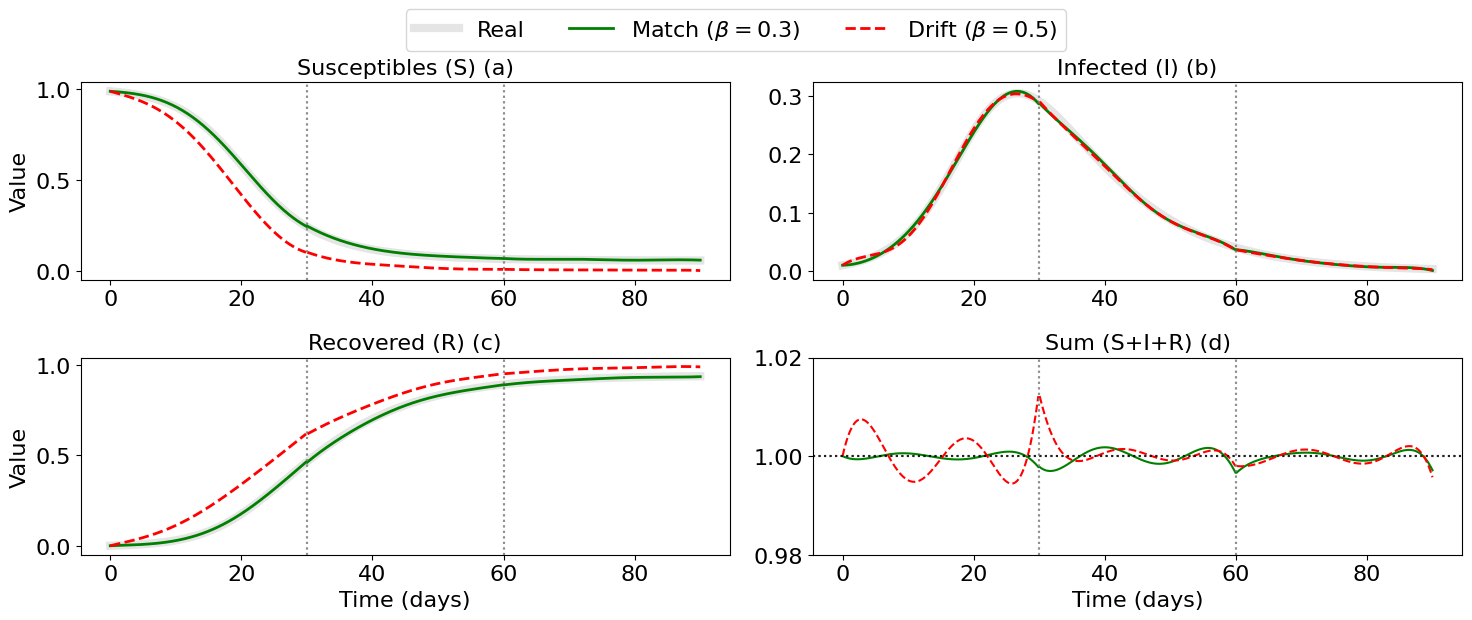

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Dtype synchronization to float32
torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Ground Truth (90 days) ---
t_max, beta_true, gamma_t = 90, 0.3, 0.1
t_eval = np.linspace(0, t_max, 450)
y0_real = [0.99, 0.01, 0.0]

def sir_model(t, y, b, g):
    S, I, R = y
    return [-b*S*I, b*S*I - g*I, g*I]

sol = solve_ivp(sir_model, [0, t_max], y0_real, args=(beta_true, gamma_t), t_eval=t_eval)

# --- 2. PINN with Hard IC (Structural Reinforcement) ---
class ResearchPINN_HardIC(nn.Module):
    def __init__(self, u0, t0, t1):
        super().__init__()
        self.t0, self.t1 = t0, t1
        self.register_buffer("u0_fixed", u0.clone().detach().float().view(1, 3))
        self.net = nn.Sequential(
            nn.Linear(1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )

    def forward(self, t):
        t_norm = 2.0 * (t - self.t0) / (self.t1 - self.t0) - 1.0
        phi = (t - self.t0)
        return self.u0_fixed + phi * self.net(t_norm)

# --- 3. Training Engine ---
def train_window(t_slice, I_slice, u0_start, beta_val):
    t_start, t_end = t_slice[0], t_slice[-1]
    model = ResearchPINN_HardIC(u0_start, t_start, t_end).to(device)
    adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, line_search_fn="strong_wolfe")
    t_tensor_win = torch.tensor(t_slice, dtype=torch.float32).view(-1, 1).to(device)
    I_obs_win = torch.tensor(I_slice, dtype=torch.float32).view(-1, 1).to(device)

    def get_loss():
        t_p = t_tensor_win.clone().requires_grad_(True)
        u = model(t_p); S, I, R = u[:, 0:1], u[:, 1:2], u[:, 2:3]
        ds = torch.autograd.grad(S, t_p, torch.ones_like(S), create_graph=True)[0]
        di = torch.autograd.grad(I, t_p, torch.ones_like(I), create_graph=True)[0]
        dr = torch.autograd.grad(R, t_p, torch.ones_like(R), create_graph=True)[0]
        res_s = ds + beta_val * S * I
        res_i = di - (beta_val * S * I - gamma_t * I)
        res_r = dr - gamma_t * I
        l_phys = torch.mean(res_s**2 + res_i**2 + res_r**2)
        l_data = torch.mean((I - I_obs_win)**2)
        l_cons = torch.mean((S + I + R - 1.0)**2)
        return l_data + l_phys + l_cons, l_data, l_phys

    for _ in range(5000):
        adam.zero_grad(); total, _, _ = get_loss(); total.backward(); adam.step()
    def closure():
        lbfgs.zero_grad(); total, _, _ = get_loss(); total.backward(); return total
    lbfgs.step(closure)
    return model

def run_windowed_simulation_hard_ic(window_duration_param):
    window_limits = np.arange(0, t_max + 1, window_duration_param)
    num_windows = len(window_limits) - 1
    models_green, models_red = [], []
    u0_g = torch.tensor(y0_real)
    u0_r = torch.tensor(y0_real)

    print(f"Running simulation with WINDOW_DURATION = {window_duration_param} days (Hard ICs)")
    for i in range(num_windows):
        start, end = window_limits[i], window_limits[i+1]
        mask = (t_eval >= start) & (t_eval <= end)
        t_win, I_win = t_eval[mask], sol.y[1][mask]

        print(f"Training Green Window {i+1}/{num_windows} (Beta 0.3)...")
        m_g = train_window(t_win, I_win, u0_g, 0.3)
        models_green.append(m_g)

        beta_red = 0.5 if i == 0 else 0.3
        print(f"Training Red Window {i+1}/{num_windows} (Beta {beta_red})...")
        m_r = train_window(t_win, I_win, u0_r, beta_red)
        models_red.append(m_r)

        with torch.no_grad():
            last_t = torch.tensor([[t_win[-1]]], device=device).float()
            u0_g = m_g(last_t).squeeze().cpu()
            u0_r = m_r(last_t).squeeze().cpu()
    return window_limits, models_green, models_red

def plot_parametric_drift(window_limits, models_green, models_red):
    plt.rcParams.update({'font.size': 16})
    fig = plt.figure(figsize=(15, 6))
    titles = ['Susceptibles (S) (a)', 'Infected (I) (b)', 'Recovered (R) (c)', 'Sum (S+I+R) (d)']
    num_windows = len(window_limits) - 1

    with torch.no_grad():
        for i in range(num_windows):
            mask = (t_eval >= window_limits[i]) & (t_eval <= window_limits[i+1])
            t_plot = torch.tensor(t_eval[mask], dtype=torch.float32).view(-1, 1).to(device)
            res_g = models_green[i](t_plot).cpu().numpy()
            res_r = models_red[i](t_plot).cpu().numpy()

            for j in range(3):
                ax = plt.subplot(2, 2, j+1)
                if i == 0: l_ode, = ax.plot(t_eval, sol.y[j], 'k-', alpha=0.1, lw=6, label='Real')
                l_match, = ax.plot(t_eval[mask], res_g[:, j], 'g-', lw=2, label=r'Match ($\beta=0.3$)' if i==0 else "")
                l_drift, = ax.plot(t_eval[mask], res_r[:, j], 'r--', lw=2, label=r'Drift ($\beta=0.5$)' if i==0 else "")
                ax.set_title(titles[j], fontweight='normal', fontsize=16)
                for k in range(1, num_windows): ax.axvline(x=window_limits[k], color='gray', linestyle=':', alpha=0.5)
                ax.grid(False)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

                if (j+1) % 2 != 0:
                    ax.set_ylabel('Value')
                if (j+1) > 2:
                    ax.set_xlabel('Time (days)')

            ax_s = plt.subplot(2, 2, 4)
            ax_s.plot(t_eval[mask], np.sum(res_g, axis=1), 'g-')
            ax_s.plot(t_eval[mask], np.sum(res_r, axis=1), 'r--')
            ax_s.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
            for k in range(1, num_windows): ax_s.axvline(x=window_limits[k], color='gray', linestyle=':', alpha=0.5)
            ax_s.set_title(titles[3], fontweight='normal', fontsize=16)
            ax_s.set_ylim(0.98, 1.02); ax_s.grid(False)
            ax_s.spines['top'].set_visible(False)
            ax_s.spines['right'].set_visible(False)
            ax_s.set_xlabel('Time (days)')

    handles = [l_ode, l_match, l_drift]
    labels = ['Real', r'Match ($\beta=0.3$)', r'Drift (Initial $\beta=0.5$)']
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=True, facecolor='white', fontsize=16)
    plt.tight_layout()
    plt.show()

# Execution
win_lim, m_green, m_red = run_windowed_simulation_hard_ic(30)
plot_parametric_drift(win_lim, m_green, m_red)

Running simulation with WINDOW_DURATION = 45 days (Hard ICs)
Training Green Window 1/2 (Beta 0.3)...
Training Red Window 1/2 (Beta 0.5)...
Training Green Window 2/2 (Beta 0.3)...
Training Red Window 2/2 (Beta 0.3)...


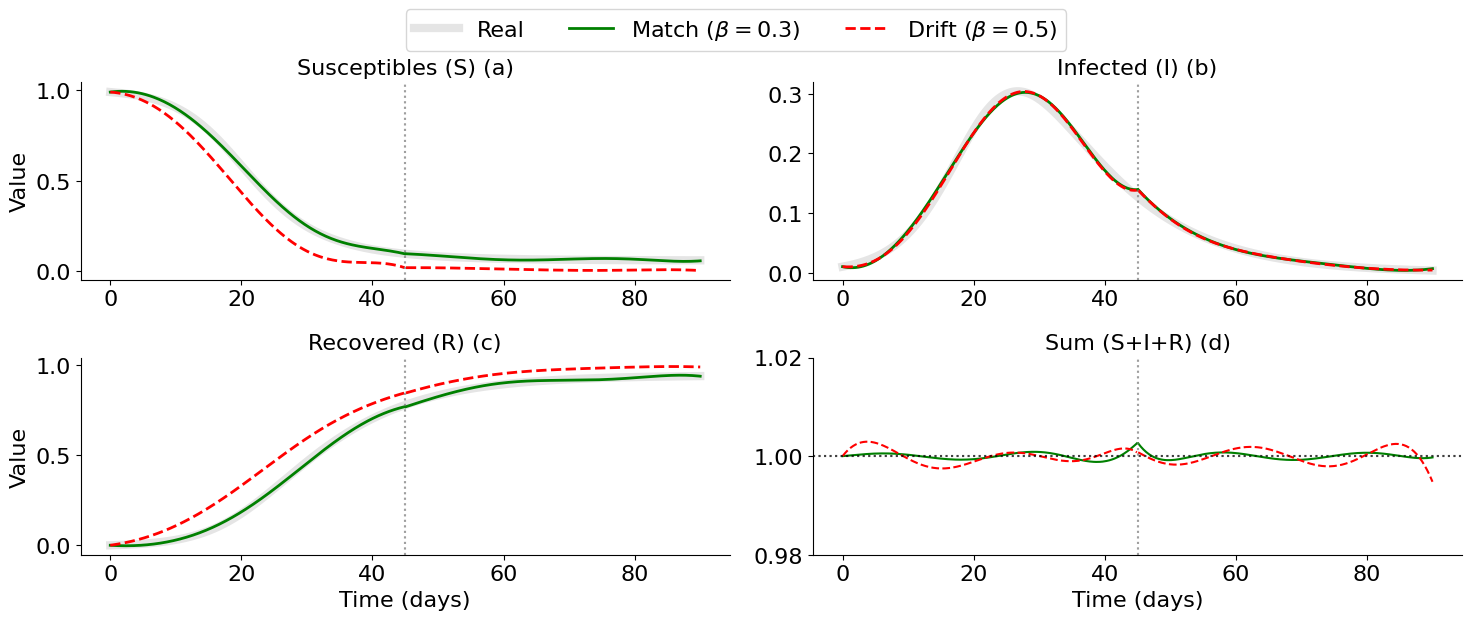

In [6]:
win_lim_45, m_green_45, m_red_45 = run_windowed_simulation_hard_ic(45)
plot_parametric_drift(win_lim_45, m_green_45, m_red_45)

Running simulation with WINDOW_DURATION = 7 days (Hard ICs)
Training Green Window 1/12 (Beta 0.3)...
Training Red Window 1/12 (Beta 0.5)...
Training Green Window 2/12 (Beta 0.3)...
Training Red Window 2/12 (Beta 0.3)...
Training Green Window 3/12 (Beta 0.3)...
Training Red Window 3/12 (Beta 0.3)...
Training Green Window 4/12 (Beta 0.3)...
Training Red Window 4/12 (Beta 0.3)...
Training Green Window 5/12 (Beta 0.3)...
Training Red Window 5/12 (Beta 0.3)...
Training Green Window 6/12 (Beta 0.3)...
Training Red Window 6/12 (Beta 0.3)...
Training Green Window 7/12 (Beta 0.3)...
Training Red Window 7/12 (Beta 0.3)...
Training Green Window 8/12 (Beta 0.3)...
Training Red Window 8/12 (Beta 0.3)...
Training Green Window 9/12 (Beta 0.3)...
Training Red Window 9/12 (Beta 0.3)...
Training Green Window 10/12 (Beta 0.3)...
Training Red Window 10/12 (Beta 0.3)...
Training Green Window 11/12 (Beta 0.3)...
Training Red Window 11/12 (Beta 0.3)...
Training Green Window 12/12 (Beta 0.3)...
Training Red W

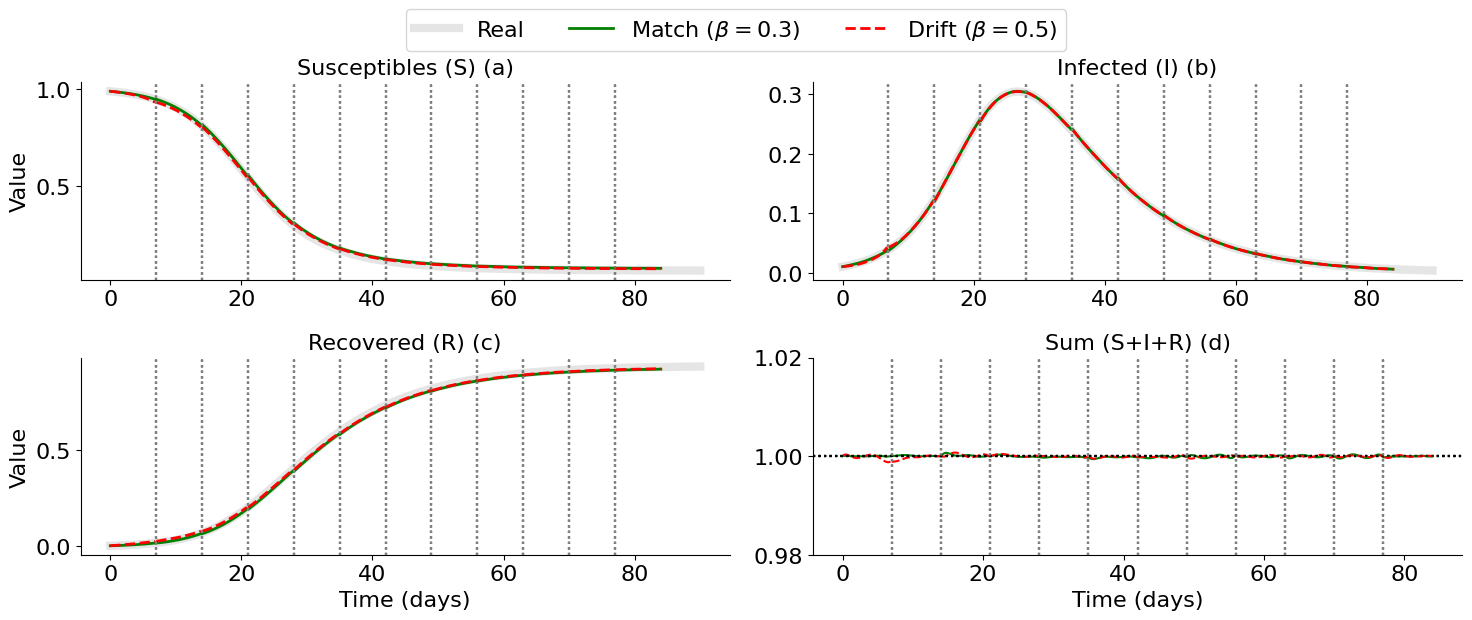

In [7]:
win_lim_7, m_green_7, m_red_7 = run_windowed_simulation_hard_ic(7)
plot_parametric_drift(win_lim_7, m_green_7, m_red_7)

Running simulation with WINDOW_DURATION = 3 days (Hard ICs)
Training Green Window 1/30 (Beta 0.3)...
Training Red Window 1/30 (Beta 0.5)...
Training Green Window 2/30 (Beta 0.3)...
Training Red Window 2/30 (Beta 0.3)...
Training Green Window 3/30 (Beta 0.3)...
Training Red Window 3/30 (Beta 0.3)...
Training Green Window 4/30 (Beta 0.3)...
Training Red Window 4/30 (Beta 0.3)...
Training Green Window 5/30 (Beta 0.3)...
Training Red Window 5/30 (Beta 0.3)...
Training Green Window 6/30 (Beta 0.3)...
Training Red Window 6/30 (Beta 0.3)...
Training Green Window 7/30 (Beta 0.3)...
Training Red Window 7/30 (Beta 0.3)...
Training Green Window 8/30 (Beta 0.3)...
Training Red Window 8/30 (Beta 0.3)...
Training Green Window 9/30 (Beta 0.3)...
Training Red Window 9/30 (Beta 0.3)...
Training Green Window 10/30 (Beta 0.3)...
Training Red Window 10/30 (Beta 0.3)...
Training Green Window 11/30 (Beta 0.3)...
Training Red Window 11/30 (Beta 0.3)...
Training Green Window 12/30 (Beta 0.3)...
Training Red W

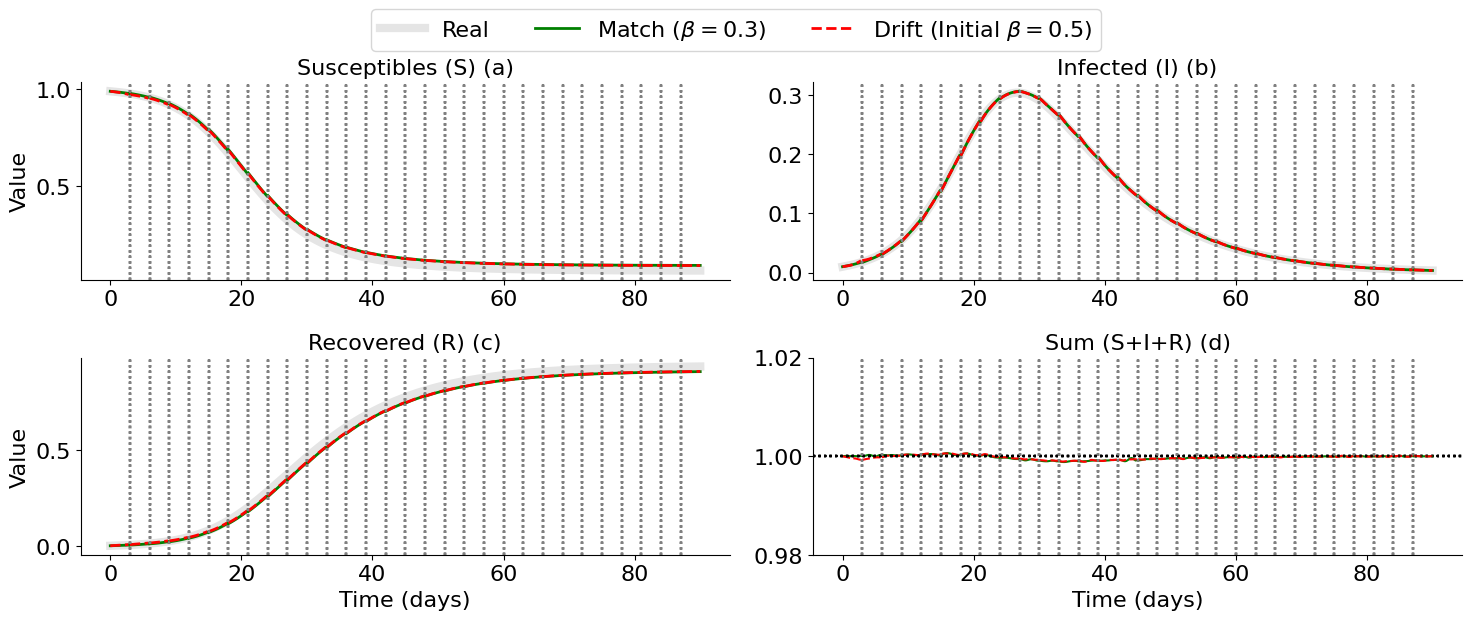

In [12]:
win_lim_3, m_green_3, m_red_3 = run_windowed_simulation_hard_ic(3)
plot_parametric_drift(win_lim_3, m_green_3, m_red_3)